 ## Lab - Week 10 - Dropout

### Ways to reduce overfitting in neural networks
 - Getting more training data
 - Reducing the capacity of the network (last week's lab)
 - Adding weight regularization (last week's lab)
 - Adding dropout (the subject for this week)
 - Using transfer learning

### Typical training and validation loss over time
![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*0VWDpLIRcMTssDf-zyOR4w.jpeg)

## Dropout Regularization

**Dropout** is a regularization technique that involves randomly "dropping out" (setting to zero) a subset of a layer's output features during training.

For example, if a layer would normally return the vector `[0.2, 0.5, 1.3, 0.8, 1.1]` for a specific input, applying dropout might result in `[0, 0.5, 1.3, 0, 1.1]`. The **dropout rate** defines the fraction of features zeroed out and typically ranges between 0.2 and 0.5.

At test time, no units are dropped. To compensate for the fact that all neurons are now active (unlike during training), the layer’s output values are scaled down by a factor equal to the dropout rate. This ensures that the expected sum of the inputs to the next layer remains consistent between training and inference.


![dropout](https://cdn-images-1.medium.com/max/1600/1*iWQzxhVlvadk6VAJjsgXgg.png)

In Keras you can introduce dropout in a network via the `Dropout` layer, which gets applied to the output of layer right before it, e.g.:
```python
model.add(layers.Dropout(0.5))
```

### Part 1: Load and Prepare Data - IMDB dataset

In [1]:
from keras import models
from keras import layers
from keras.datasets import imdb
import numpy as np

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
      for j in sequence:
        results[i, j] += 1
    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
# Our vectorized labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**As a routine, perform a sanity check on the dataset to understand the shape of the train and test inputs and outputs, and print out a sample of the data.**

In [2]:
#TODO
#your code here
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

print("\nFirst 10 values of the first training sample:")
print(x_train[0][:10])

print("\nFirst 5 labels:")
print(y_train[:5])

print("\nUnique labels:")
print(np.unique(y_train))

x_train shape: (25000, 10000)
y_train shape: (25000,)
x_test shape: (25000, 10000)
y_test shape: (25000,)

First 10 values of the first training sample:
[ 0.  1.  6.  0. 15.  9.  3.  2.  3.  1.]

First 5 labels:
[1. 0. 0. 1. 0.]

Unique labels:
[0. 1.]


### Part 2: Build a Simple Neural Network Model
Objective: Create a basic neural network model using Keras.

**Questions**
- What type of classification problem are we solving?: **binary classification**
- How many neurons should there be in the output layer?: **1**
- What should be the activation function of the output layer?: **sigmoid**
- What loss function should be used?: **binary crossentropy**
- What activation function should be used on the hidden layers?: **relu**


Build a sequential model with one dense layer with 8 units and train it for 20 epochs.

Complete the code below:

In [8]:
# TODO fix this code
  # Add a single hidden layer with 8 units and proper activation
  # Compile the model with an appropriate optimizer, loss function, and evaluation metric.
  # Show the summary of the model

model = models.Sequential()
model.add(layers.InputLayer(shape=(10000,)))
model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │        80,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,017 (312.57 KB)

 Trainable params: 80,017 (312.57 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train the model
hist_a = model.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))

# Evaluate the model
evaluation_results = model.evaluate(x_test, y_test)
print("Test accuracy:", evaluation_results[1])

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.7999 - loss: 0.4695 - val_accuracy: 0.8718 - val_loss: 0.3555
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9056 - loss: 0.2788 - val_accuracy: 0.8859 - val_loss: 0.3084
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9288 - loss: 0.2228 - val_accuracy: 0.8867 - val_loss: 0.2941
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9384 - loss: 0.1912 - val_accuracy: 0.8865 - val_loss: 0.2933
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9476 - loss: 0.1683 - val_accuracy: 0.8853 - val_loss: 0.2943
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9545 - loss: 0.1498 - val_accuracy: 0.8827 - val_loss: 0.3046
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9590 - loss: 0.1365 - val_accuracy: 0.8810 - val_loss: 0.3095
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9641 - loss: 0.1241 - val_accuracy: 0.8778 - v

### Part 3: Visualize Training and Validation Performance

The function below can be used later to plot the loss and accuracy from the model training history

In [16]:
# Helper function

import matplotlib.pyplot as plt
# colors will be used to plot the different models below
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

def plot_history(history, color='blue', prefix=""):
    history_dict = history.history
    loss_values = history_dict["loss"]
    val_loss_values = history_dict["val_loss"]
    epochs = range(1, len(loss_values) + 1)

    # Make a figure with two subplots side by side
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)

    # Plot the loss
    plt.plot(epochs, loss_values, "o",  color=color, label=prefix + " Training loss")
    plt.plot(epochs, val_loss_values, color=color, label=prefix + " Validation loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(framealpha=0.5)
    plt.grid()

    # Plot the accuracy
    plt.subplot(1, 2, 2)
    acc_values = history_dict["accuracy"]
    val_acc_values = history_dict["val_accuracy"]
    # Skip plotting the training accuracy, it makes the plot harder to read
    # plt.plot(epochs, acc_values, "o", color=color , label=prefix + " Training accuracy")
    plt.plot(epochs, val_acc_values, color=color, label=prefix + " Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(framealpha=0.5)
    plt.grid()

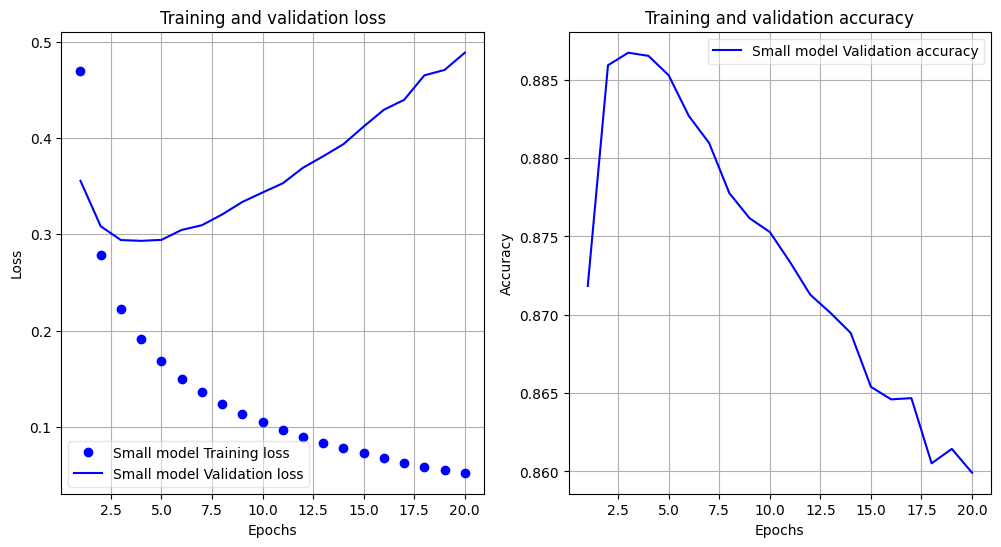

In [17]:
# Using the plotting function

plot_history(hist_a, color='blue', prefix="Small model")

### Part 4: Add Dropout Regularization
Objective: Experiment with dropout layers in the model.

**Instructions:**
1. Add another hidden layer with 8 units
1. Add dropout layers after each hidden layer with a dropout rate of 0.3.
1. Compile the model.
1. Train the model and observe the changes in accuracy.

Complete the code below:

In [18]:
# TODO: Build a model with 30% Dropout
drp_model = models.Sequential()
drp_model.add(layers.InputLayer(shape=(10000,)))

drp_model.add(layers.Dense(8, activation='relu'))
drp_model.add(layers.Dropout(0.3))

drp_model.add(layers.Dense(8, activation='relu'))
drp_model.add(layers.Dropout(0.3))

drp_model.add(layers.Dense(1, activation='sigmoid'))

drp_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


drp_history = drp_model.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.5963 - loss: 0.6696 - val_accuracy: 0.7848 - val_loss: 0.6255
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7352 - loss: 0.5843 - val_accuracy: 0.8647 - val_loss: 0.4996
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8052 - loss: 0.4874 - val_accuracy: 0.8720 - val_loss: 0.4260
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8484 - loss: 0.4011 - val_accuracy: 0.8842 - val_loss: 0.3329
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8793 - loss: 0.3343 - val_accuracy: 0.8854 - val_loss: 0.3016
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9053 - loss: 0.2785 - val_accuracy: 0.8881 - val_loss: 0.2912
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9186 - loss: 0.2402 - val_accuracy: 0.8871 - val_loss: 0.2937
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9295 - loss: 0.2094 - val_accuracy: 0.8859 - 

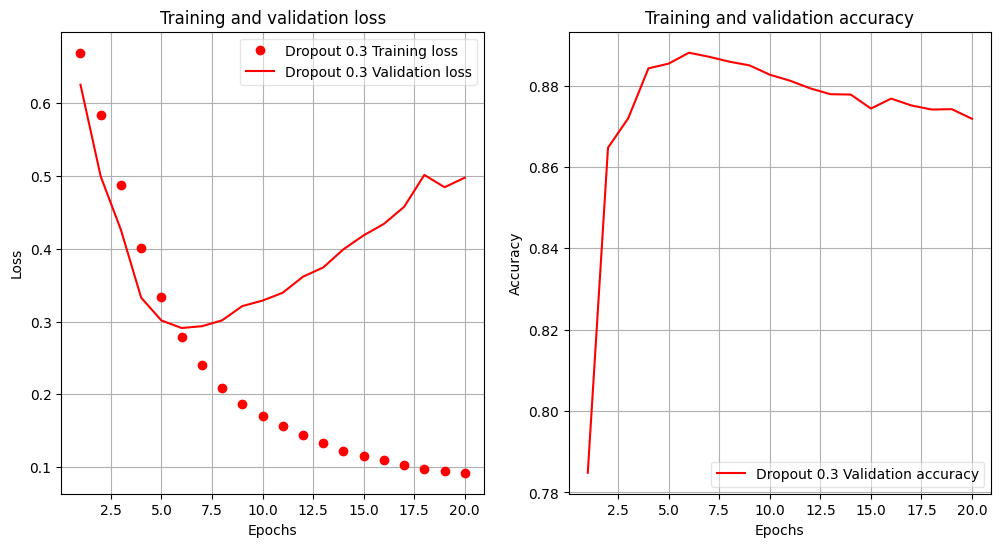

In [19]:
# Plot training history
plot_history(drp_history, color='red', prefix="Dropout 0.3")

### Part 5: Test Different Dropout Rates
Objective: Compare the model's performance with varying dropout rates.

**Instructions:**
1. Write a loop to create and train models with dropout rates of `[0, 0.2, 0.3, 0.4, 0.5]`.
2. For each model, record the history to plot it later


Complete the code below:

In [21]:
# TODO: try different dropout rates

rates = [0, 0.2, 0.3, 0.4, 0.5]
hists = []

for rate in rates:
    print(f"Training model with dropout rate: {rate}")
    model = models.Sequential()
    model.add(layers.InputLayer(shape=(10000,)))

    model.add(layers.Dense(8, activation='relu'))
    model.add(layers.Dropout(rate))

    model.add(layers.Dense(8, activation='relu'))
    model.add(layers.Dropout(rate))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    hist = model.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))
    hists.append(hist)



Training model with dropout rate: 0
Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.7575 - loss: 0.5460 - val_accuracy: 0.8508 - val_loss: 0.4142
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8988 - loss: 0.3098 - val_accuracy: 0.8845 - val_loss: 0.3135
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9257 - loss: 0.2279 - val_accuracy: 0.8866 - val_loss: 0.2964
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9397 - loss: 0.1853 - val_accuracy: 0.8869 - val_loss: 0.2938
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9508 - loss: 0.1557 - val_accuracy: 0.8830 - val_loss: 0.3047
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9570 - loss: 0.1335 - val_accuracy: 0.8812 - val_loss: 0.3190
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9646 - loss: 0.1162 - val_accuracy: 0.8775 - val_loss: 0.3391
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9709 - los

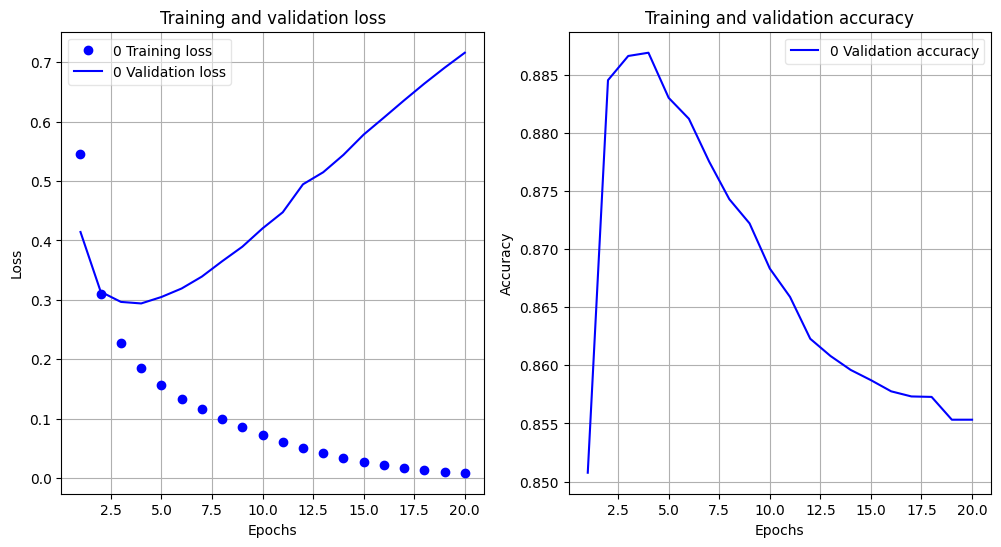

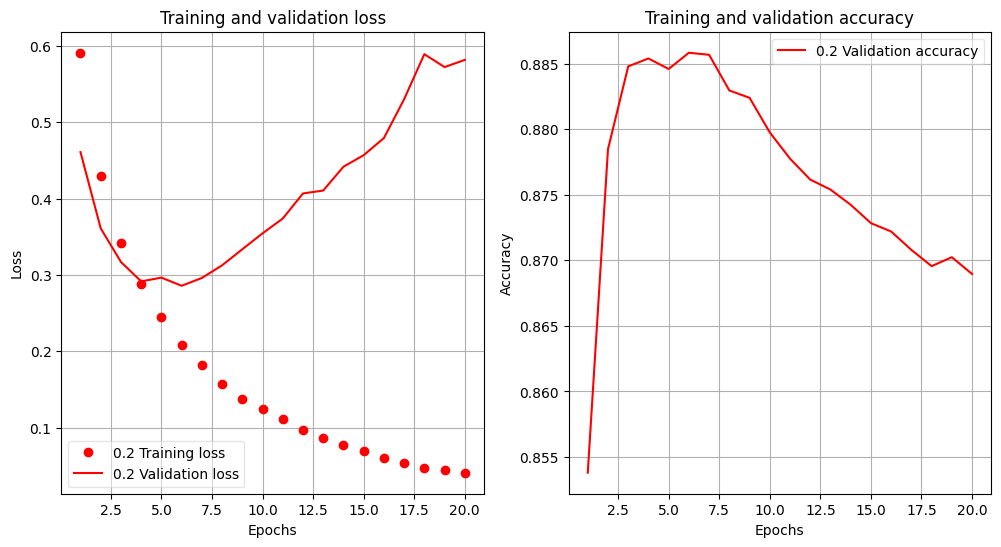

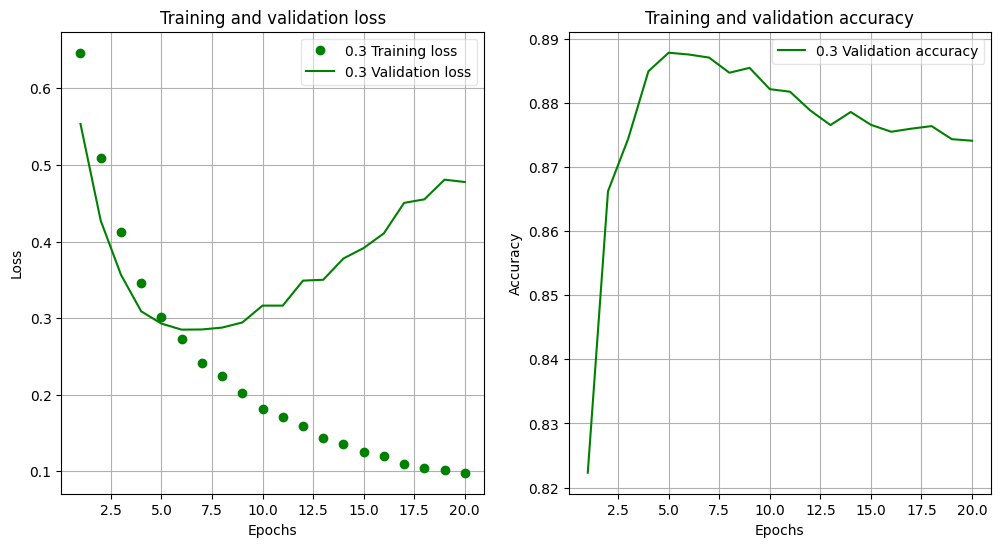

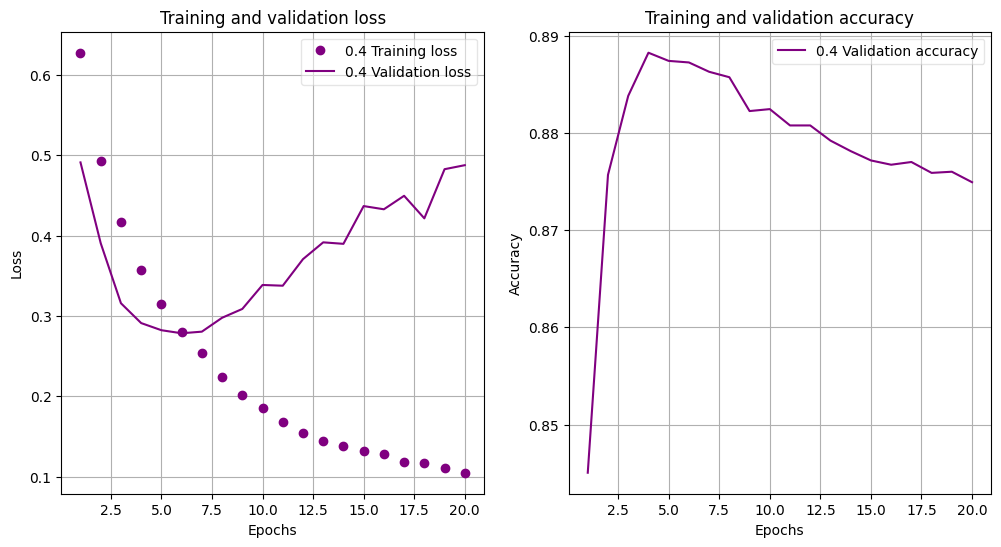

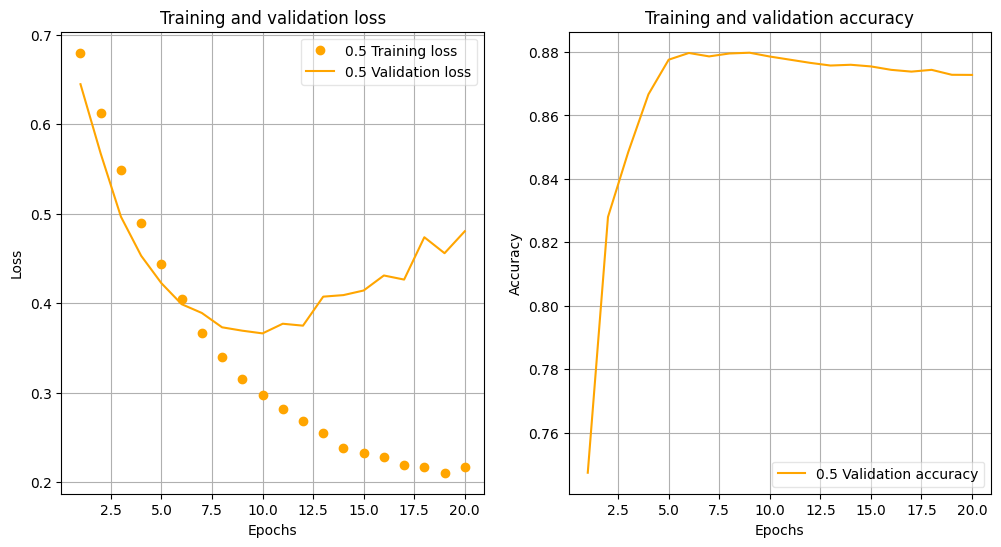

In [22]:
for i, hist in enumerate(hists):
    plot_history(hist, colors[i], prefix=str(rates[i]))

### Part 6: Experiment with dropout location
Objective: Compare the model's performance with dropout placed after different layers

**Instructions:**
Create 3 models with a single dropout "layer" placed:
1. Before the first dense layer only
2. After the first dense layer only
3. After the second dense layer only



Complete the code below:

In [23]:
hists_b = [] #append the training history of 3 cases mentioned above
rate = 0.4
#TODO: your code here

# before the first dense layer
model1 = models.Sequential()
model1.add(layers.Input(shape=(10000,)))

model1.add(layers.Dropout(0.4))

model1.add(layers.Dense(8, activation='relu'))
model1.add(layers.Dense(8, activation='relu'))
model1.add(layers.Dense(1, activation='sigmoid'))

model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

hist1 = model1.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))

# after the first dense layer
model2 = models.Sequential()
model2.add(layers.Input(shape=(10000,)))

model2.add(layers.Dense(8, activation='relu'))
model2.add(layers.Dropout(0.4))

model2.add(layers.Dense(8, activation='relu'))
model2.add(layers.Dense(1, activation='sigmoid'))

model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

hist2 = model2.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))


# after second dense layer
model3 = models.Sequential()
model3.add(layers.Input(shape=(10000,)))

model3.add(layers.Dense(8, activation='relu'))
model3.add(layers.Dense(8, activation='relu'))
model3.add(layers.Dropout(0.4))

model3.add(layers.Dense(1, activation='sigmoid'))

model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

hist3 = model3.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.7427 - loss: 0.5478 - val_accuracy: 0.8607 - val_loss: 0.4038
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.8606 - loss: 0.3609 - val_accuracy: 0.8820 - val_loss: 0.3270
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.8821 - loss: 0.3064 - val_accuracy: 0.8871 - val_loss: 0.3033
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.8905 - loss: 0.2769 - val_accuracy: 0.8887 - val_loss: 0.2935
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.9004 - loss: 0.2555 - val_accuracy: 0.8864 - val_loss: 0.2942
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.9030 - loss: 0.2477 - val_accuracy: 0.8853 - val_loss: 0.2938
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.9042 - loss: 0.2410 - val_accuracy: 0.8826 - val_loss: 0.3024
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.9044 - loss: 0.2366 - val_accuracy: 0.8

In [31]:
hists_b.append(hist1)
hists_b.append(hist2)
hists_b.append(hist3)

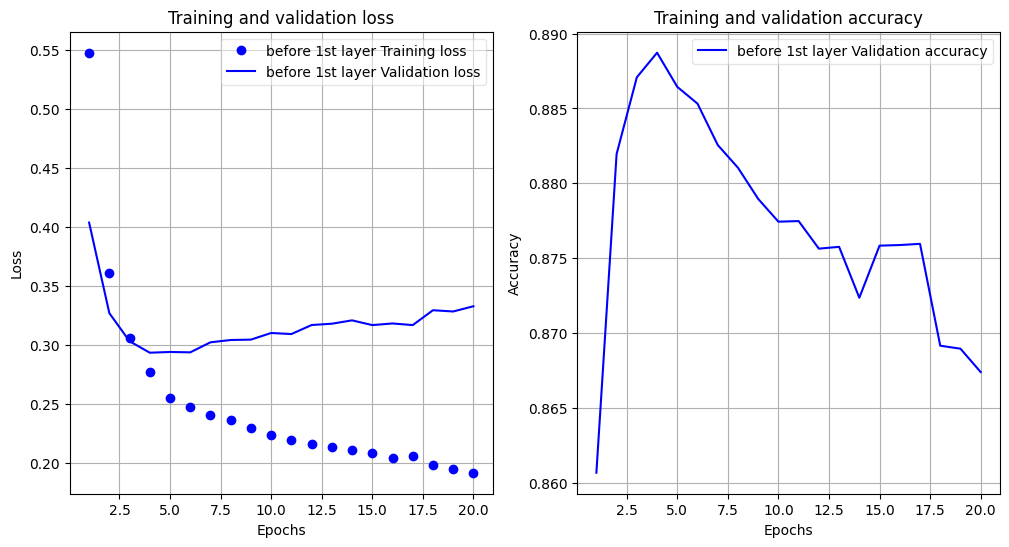

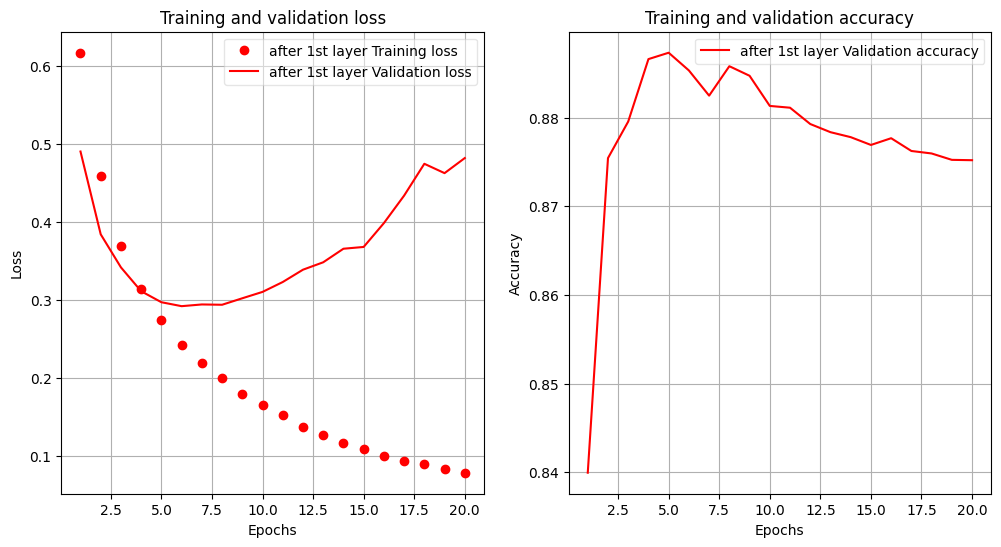

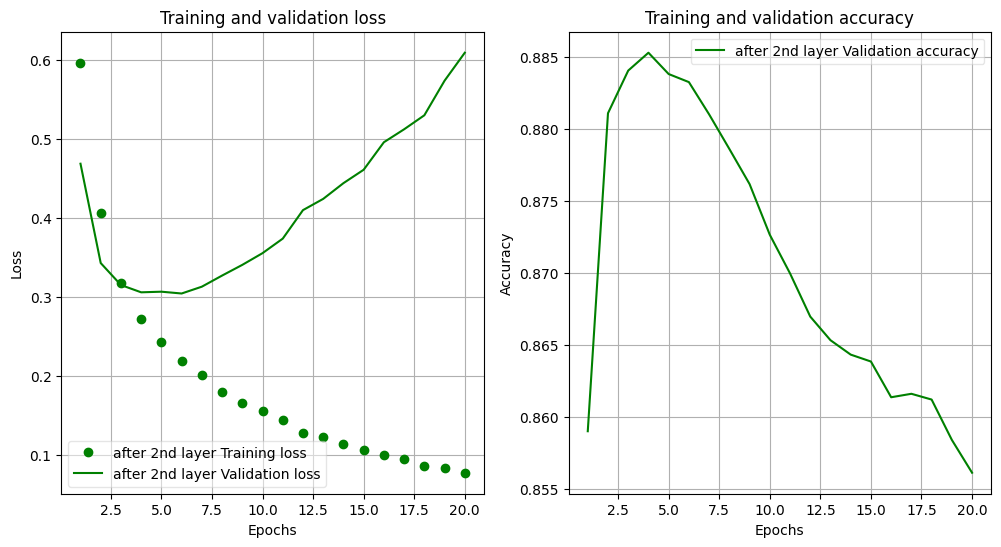

In [33]:
prefixes = ['before 1st layer', 'after 1st layer', 'after 2nd layer']
for i, hist in enumerate(hists_b):
    plot_history(hist, colors[i], prefix=prefixes[i])